# Apparent Non-causalities in FRFs
A fundamental problem in transient ISE is that the FRFs typically have apparent non-causalities. This notebook will demonstrate three scenarios that can cause apparent non-causalities in the FRFs:

- Band limited FRF estimation
- Frequency dependent weightings or transformations
- Frequency dependent regularization

## Importing the Beam Model and Computing Causal FRFs
This notebook will only review the FRFs of the nominal beam system for the apparent non-causalities, it will not estimate forces with the computed FRFs. Causal FRFs are being approximated by computing the FRFs to 5,000 Hz, which is an extremely high frequency bandwidth compared with the highest natural frequency of the system. These FRFs are being computed with the `frequency_response` method in SDynPy, which uses the physical system mass, stiffness, and damping matrices from the `System` object. The FRFs that are computed to the extremely high frequency are referred to as the `oversampled_frfs`.

In [1]:
import sdynpy as sdpy
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import irfft
from scipy.signal import hilbert
plt.rcParams.update({'font.size':10,
                     'font.family':'Times New Roman'})

In [2]:
nominal_beam_system = sdpy.System.load(r'system_data/nominal_beam_system.npz')

In [3]:
Fs = 10000 #Hz
T = 1 # seconds
frequency = np.arange(stop=Fs/2+1/T, step=1/T)

In [4]:
response_coordinate = sdpy.coordinate_array(node=[102,104,106,108], direction=3)
reference_coordinate = sdpy.coordinate_array(string_array=['103Z+', '104Z+'])

oversampled_frfs = nominal_beam_system.frequency_response(frequency, responses=response_coordinate, 
                                                  references=reference_coordinate, displacement_derivative=2)

The plot below shows a sample IRF (that is computed with the `ifft` method for the `TransferFunctionArray` object) to demonstrate that the FRFs with a high sampling frequency are approximately causal, since the IRFs ring to nearly zero amplitude at the end of the time range. However, close inspection shows that there is still a small uptick at the end of the IRF, which is due to the FRFs not being computed to infinite frequencies.

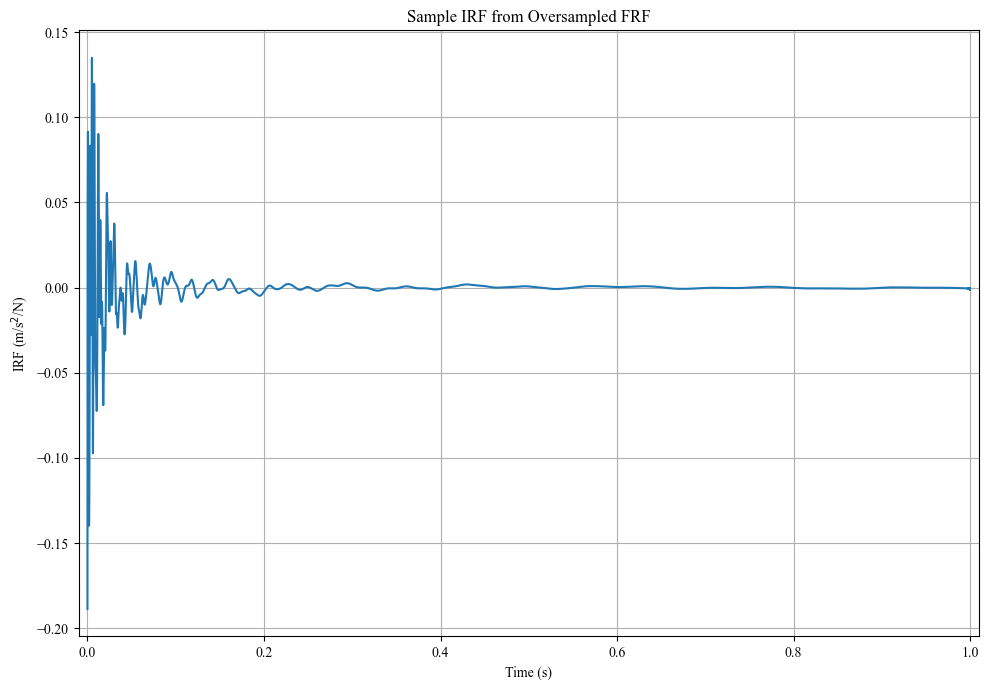

In [12]:
plt.figure(figsize=(10,7))
plt.plot(oversampled_frfs.ifft()[2,1].abscissa, oversampled_frfs.ifft()[2,1].ordinate)
plt.xlim(left=-0.01, right=T+0.01); plt.xlabel('Time (s)'); plt.ylabel('IRF (m/s$^2$/N)')
plt.grid(); plt.title('Sample IRF from Oversampled FRF'); plt.tight_layout()

(sec:band_limited_frfs)=
## Band Limited FRFs
Band limited FRFs are likely the most common reason for apparent non-causalities in the FRFs since any practical scenario will not estimate FRFs to infinite frequencies. The effects of the frequency truncation will be shown below by extracting the 0-500 Hz portion of the FRF using the `extract_elements_by_abscissa` method in SDynPy and computing the IRF via the inverse DFT of the truncated FRFs. The truncated frequency range is shown in the sample FRF plot below as the region that is highlighted red. 

In [6]:
undersampled_band = (0,500)

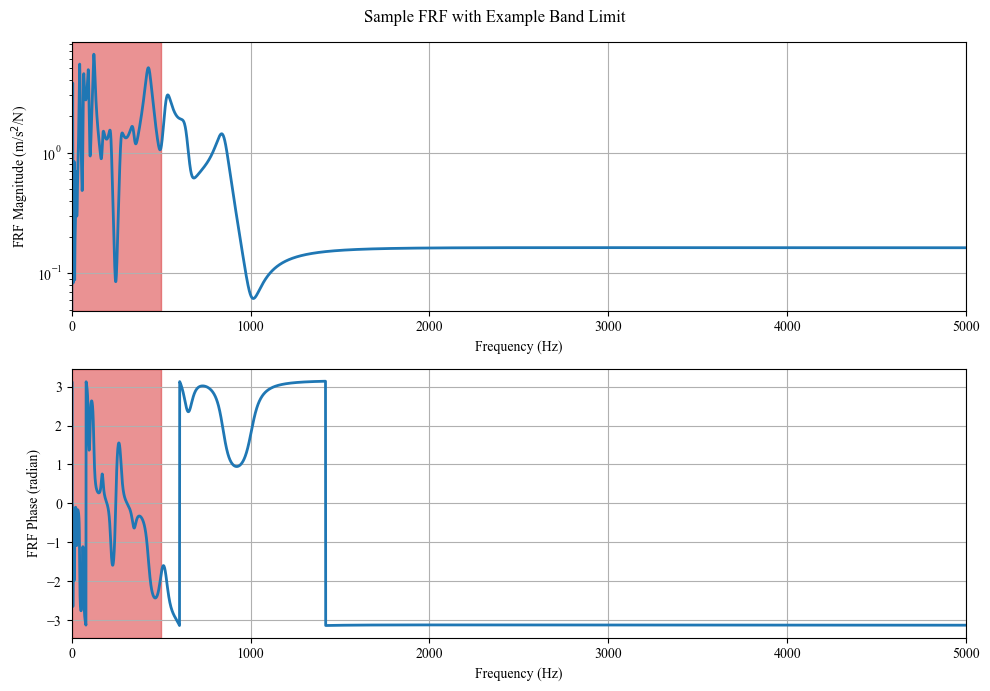

In [7]:
fig, ax = plt.subplots(2,1, figsize=(10,7))

ax_ind = 0
ax[ax_ind].semilogy(oversampled_frfs[0,1].abscissa, np.abs(oversampled_frfs[0,1].ordinate), 
                    linewidth=2)
ax[ax_ind].set_xlabel('Frequency (Hz)'); ax[ax_ind].set_ylabel('FRF Magnitude (m/s$^2$/N)')
ax[ax_ind].set_xlim(left=0, right=Fs/2); ax[ax_ind].grid()
ax[ax_ind].axvspan(xmin=undersampled_band[0], xmax=undersampled_band[-1], alpha=0.5, color='tab:red')

ax_ind = 1
ax[ax_ind].plot(oversampled_frfs[0,1].abscissa, np.angle(oversampled_frfs[0,1].ordinate), 
                linewidth=2)
ax[ax_ind].set_xlabel('Frequency (Hz)'); ax[ax_ind].set_ylabel('FRF Phase (radian)')
ax[ax_ind].set_xlim(left=0, right=Fs/2); ax[ax_ind].grid()
ax[ax_ind].axvspan(xmin=undersampled_band[0], xmax=undersampled_band[-1], alpha=0.5, color='tab:red')

fig.suptitle('Sample FRF with Example Band Limit')
fig.tight_layout()

The apparent non-causality is obvious in the plot below, where the band limited IRF shows a significant ring-up at the end of the time period. Note that this is referred to as an apparent non-causality because the free response of the system decays to relatively low response levels, then increases again. The only excitation in the IRF occurs at zero time, so the periodic nature of the Fourier transform implies that the system is responding before there is excitation. 

In [8]:
undersampled_frfs = oversampled_frfs.extract_elements_by_abscissa(*undersampled_band)

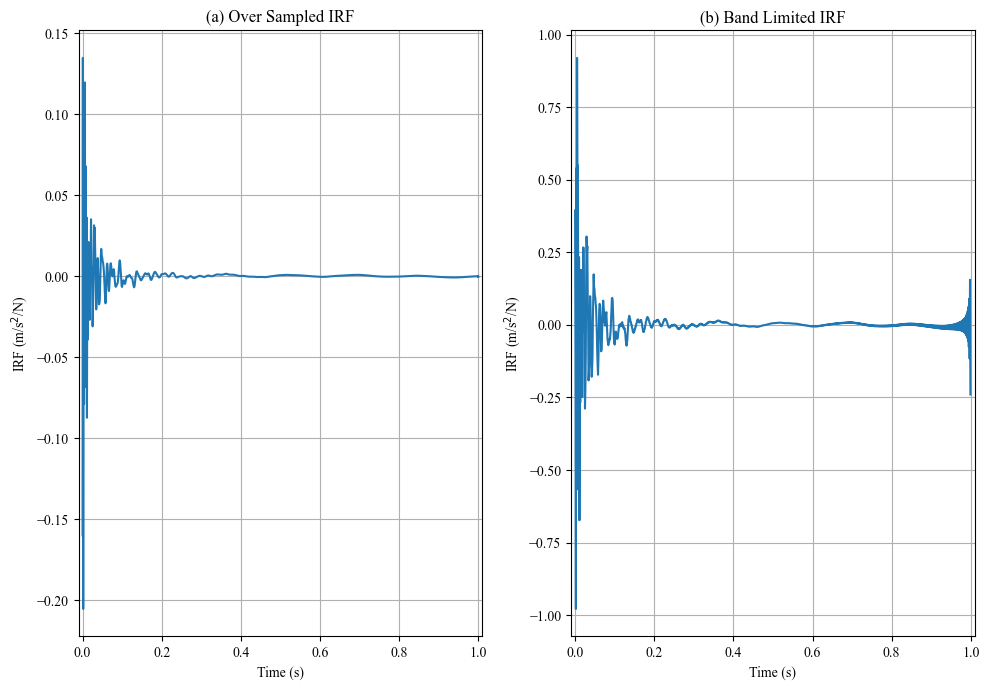

In [9]:
fig, ax = plt.subplots(1,2,figsize=(10,7))

ax[0].plot(oversampled_frfs.ifft()[0,1].abscissa, oversampled_frfs.ifft()[0,1].ordinate)
ax[0].set_xlabel('Time (s)'); ax[0].set_xlim(left=-0.01, right=T+0.01); ax[0].set_ylabel('IRF (m/s$^2$/N)')
ax[0].set_title('(a) Over Sampled IRF'); ax[0].grid(zorder=0)

ax[1].plot(undersampled_frfs.ifft()[0,1].abscissa, undersampled_frfs.ifft()[0,1].ordinate)
ax[1].set_xlabel('Time (s)'); ax[1].set_xlim(left=-0.01, right=T+0.01); ax[1].set_ylabel('IRF (m/s$^2$/N)')
ax[1].set_title('(b) Band Limited IRF'); ax[1].grid(zorder=0)

fig.tight_layout()

### Mitigating Non-causalities from Band Limited FRFs
It has been the authors experience that the apparent non-causalities in the band limited FRFs can be mitigated by either estimating the FRFs to extremely high frequencies or selecting a "good" bandwidth. Anecdotally, it appears that good bandwidths may stop at anti-resonances with deep troughs, which is demonstrated in the plot below by truncating the FRFs to the 0-240 Hz bandwidth. 

```{note}
It is generally not possible to truncate the FRFs to a frequency that falls at an anti-resonance with a trough that is deep enough for the mitigation to work in ISE scenarios with multiple sources and responses, since not all response and/or source DOFs will have troughs at the same frequencies. Further, not all DOFs will have troughs that are deep enough for this mitigation to work. This issue can be seen by changing the response and reference DOFs in the plot below.
```

In [ ]:
undersampled_band_good = (0,240)
undersampled_frfs_good = oversampled_frfs.extract_elements_by_abscissa(*undersampled_band_good)

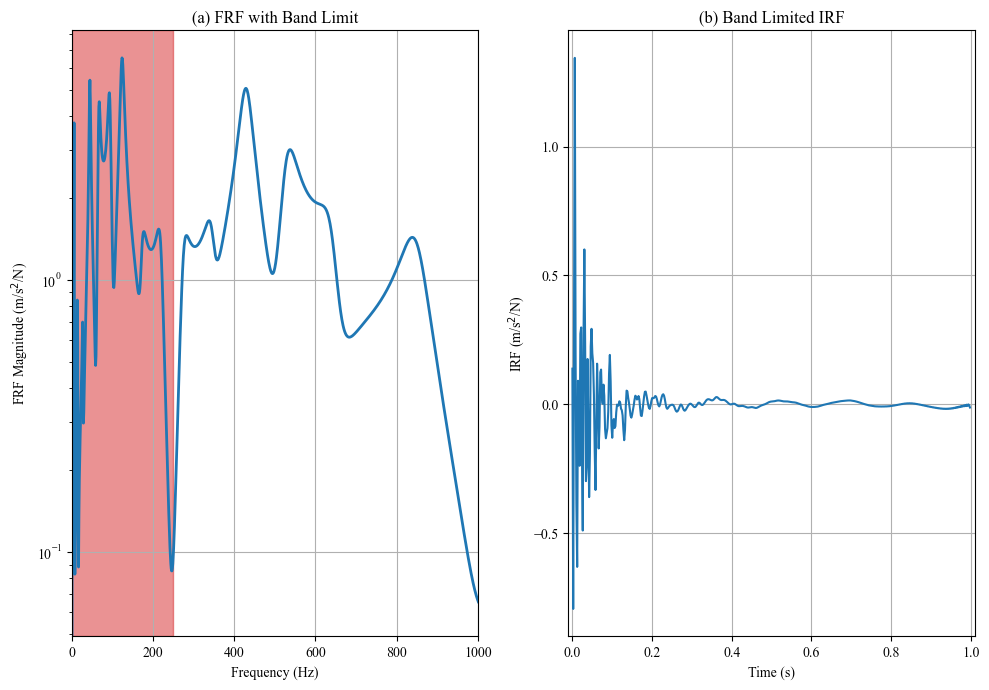

In [21]:
fig, ax = plt.subplots(1,2,figsize=(10,7))

ax[0].semilogy(oversampled_frfs[0,1].abscissa, np.abs(oversampled_frfs[0,1].ordinate), 
                    linewidth=2)
ax[0].set_xlabel('Frequency (Hz)'); ax[0].set_ylabel('FRF Magnitude (m/s$^2$/N)')
ax[0].set_xlim(left=0, right=1000); ax[0].grid()
ax[0].axvspan(xmin=undersampled_band_good[0], xmax=undersampled_band_good[-1], alpha=0.5, color='tab:red')
ax[0].set_title('(a) FRF with Band Limit')

ax[1].plot(undersampled_frfs_good.ifft()[0,1].abscissa, undersampled_frfs_good.ifft()[0,1].ordinate)
ax[1].set_xlabel('Time (s)'); ax[1].set_xlim(left=-0.01, right=T+0.01); ax[1].set_ylabel('IRF (m/s$^2$/N)')
ax[1].set_title('(b) Band Limited IRF'); ax[1].grid(zorder=0)

fig.tight_layout()

## Frequency Dependent Weighting and Transformations
Frequency dependent weightings and transformations can also induce apparent non-causalities in the FRFs. This is demonstrated below by creating a frequency dependent weighting that multiplies the FRFs by 0.1 at frequencies greater than 2000 Hz. This weighting is shown in the plot below.  

In [22]:
weighting = np.array([1]*frequency.shape[0], dtype=float) 
weighting[2000:] *= 0.1

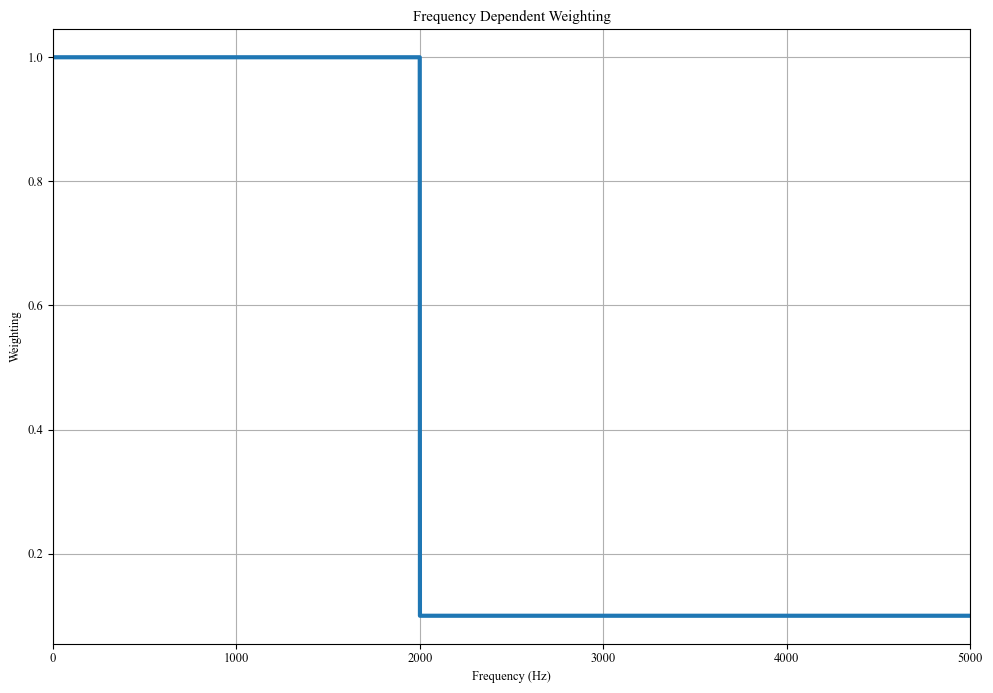

In [31]:
plt.figure(figsize=(10,7))
plt.plot(frequency, weighting, linewidth=3)
plt.xlim(left=0, right=frequency.max()); plt.xlabel('Frequency (Hz)'); plt.ylabel('Weighting')
plt.grid(); plt.title('Frequency Dependent Weighting'); plt.tight_layout()

The frequency dependent weighting is applied to a single FRF through simple element-wise multiplication. A plot of the IRF from the weighted FRF clearly shows that the frequency dependent weighting induces an apparent non-causality on the system. 

In [26]:
weighted_frf = oversampled_frfs[0,1].ordinate*weighting
weighted_irf = irfft(weighted_frf, norm='backward')
irf_time = np.arange(Fs)/Fs

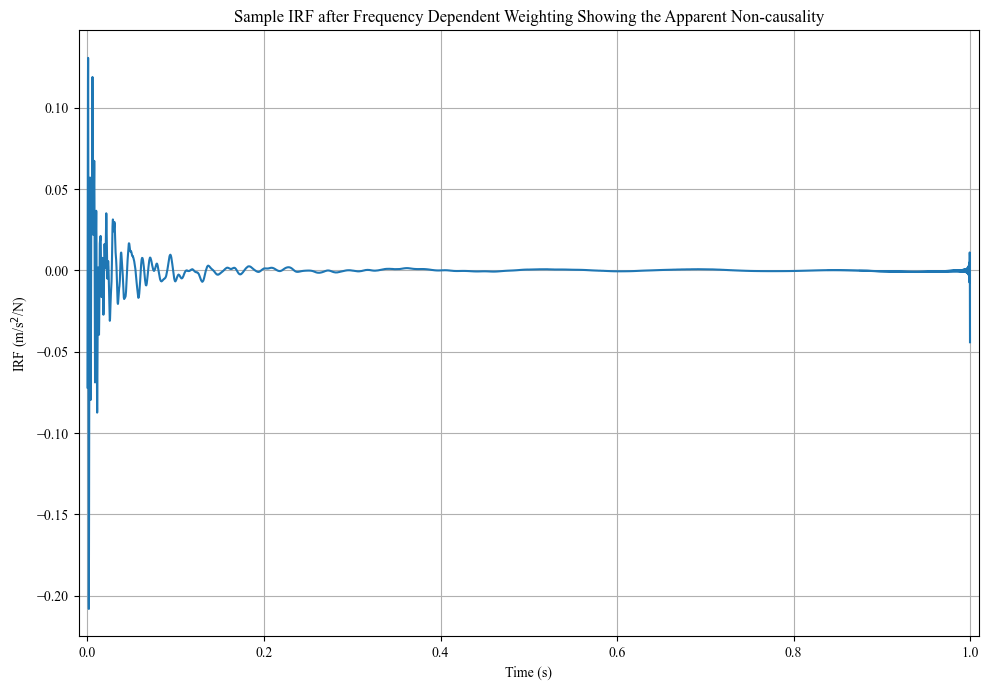

In [27]:
plt.figure(figsize=(10,7))
plt.plot(irf_time, weighted_irf)
plt.xlim(left=-0.01, right=T+0.01); plt.xlabel('Time (s)'); plt.ylabel('IRF (m/s$^2$/N)')
plt.grid(); plt.title('Sample IRF after Frequency Dependent Weighting Showing the Apparent Non-causality');
plt.tight_layout()

### Causal Approximation of the Frequency Dependent Weighting
A causal approximation of the frequency dependent weighting can be derived using its Hilbert transform. The general process for generating the causal approximation of the weighting is:

1. The weighting is converted to a two sided function with positive and negative frequencies
2. The Hilbert transform is taken of the two sided weighting
3. The imaginary portion is extracted from the Hilbert transform and then multiplied by negative one
4. The causal frequency dependent weighting is approximated by combining the original frequency dependent weighting with the imaginary portion of the Hilbert (from step three)

In [28]:
weighting_two_sided = np.concatenate((np.flip(weighting[1:]), weighting))
weighting_imaginary_part = -np.imag(hilbert(weighting_two_sided))

causal_weighting = weighting_two_sided+1j*weighting_imaginary_part
causal_weighting = causal_weighting[-frequency.shape[0]:]

The causal approximation of the weighting is applied to the FRFs with the same element-wise multiplication that was used above. The plot below shows a sample IRF (with the same reference and response DOFs as before) after applying the causal weighting to the FRF. This IRF does not exhibit any ring-up at the end of the time duration.

In [29]:
causal_weighted_frf = oversampled_frfs[0,1].ordinate*causal_weighting
causal_weighted_irf = irfft(causal_weighted_frf, norm='backward')

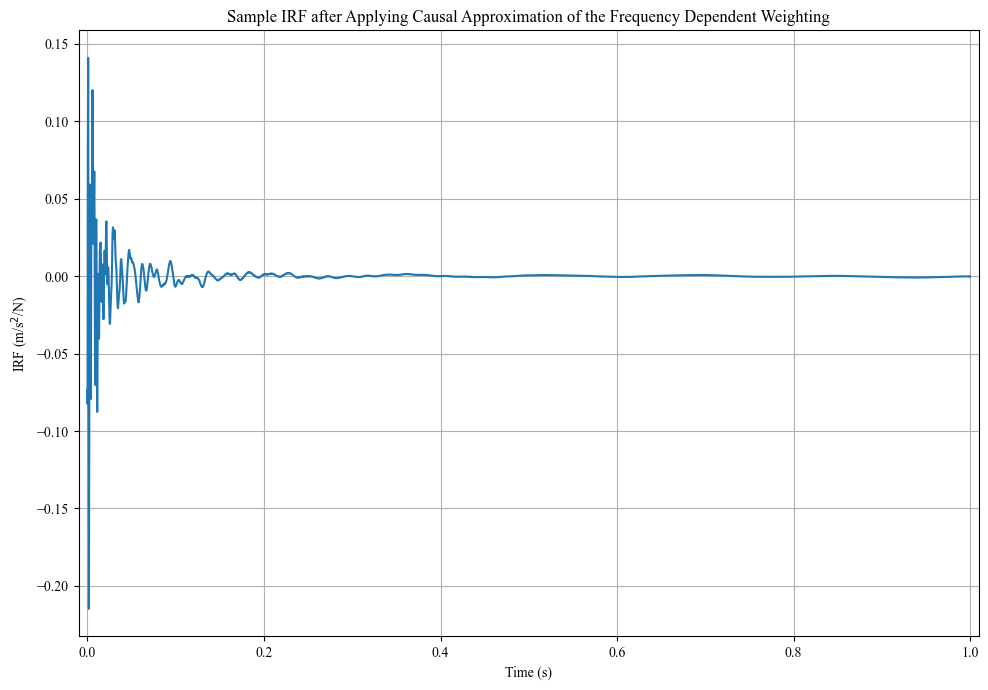

In [30]:
plt.figure(figsize=(10,7))
plt.plot(irf_time, causal_weighted_irf)
plt.xlim(left=-0.01, right=T+0.01); plt.xlabel('Time (s)'); plt.ylabel('IRF (m/s$^2$/N)')
plt.grid(); plt.title('Sample IRF after Applying Causal Approximation of the Frequency Dependent Weighting');
plt.tight_layout()

It is important to note that the process for generating the causal approximation of the weighting has a significant influence on both the magnitude and phase of the weighting, as shown in the plot below. Consequently, the causal weighting may no longer influence the FRFs in the same way as the original weighting. 

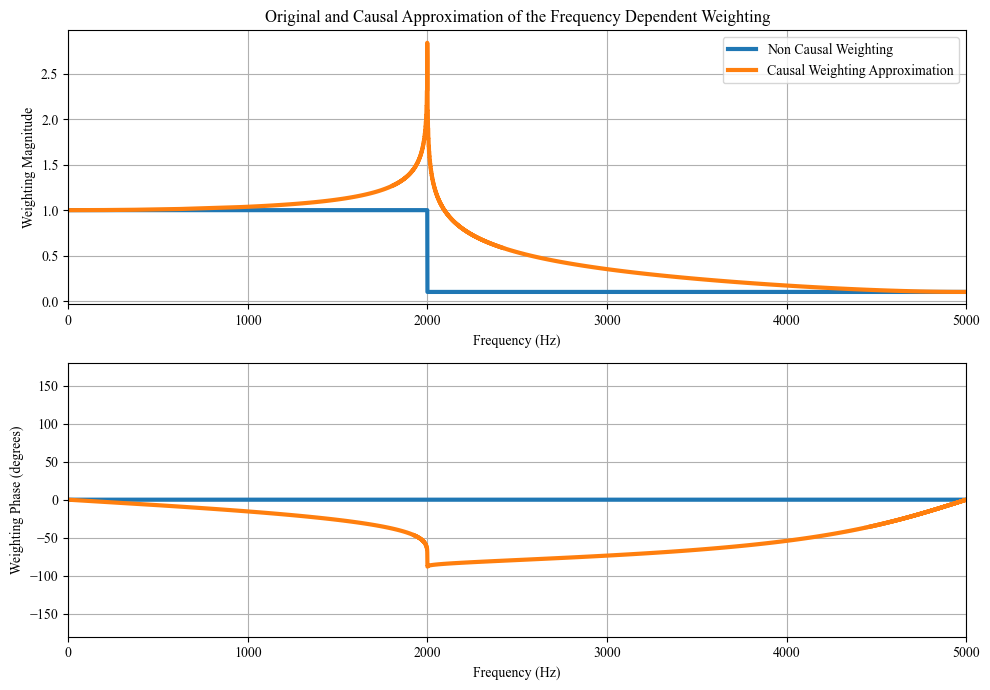

In [31]:
fig, ax = plt.subplots(2,1,figsize=(10,7))

ax_ind=0
ax[ax_ind].plot(frequency, np.abs(weighting), linewidth=3, label='Non Causal Weighting')
ax[ax_ind].plot(frequency, np.abs(causal_weighting), linewidth=3, label='Causal Weighting Approximation')
ax[ax_ind].set_ylabel('Weighting Magnitude'); ax[ax_ind].set_xlabel('Frequency (Hz)')
ax[ax_ind].grid(); ax[ax_ind].legend(); ax[ax_ind].set_xlim(left=0, right=frequency.max())
ax[ax_ind].set_title('Original and Causal Approximation of the Frequency Dependent Weighting')

ax_ind=1
ax[ax_ind].plot(frequency, np.angle(weighting)*180/np.pi, linewidth=3)
ax[ax_ind].plot(frequency, np.angle(causal_weighting)*180/np.pi, linewidth=3)
ax[ax_ind].set_ylabel('Weighting Phase (degrees)'); ax[ax_ind].set_xlabel('Frequency (Hz)')
ax[ax_ind].set_xlim(left=0, right=frequency.max()); ax[ax_ind].set_ylim(bottom=-180, top=180)
ax[ax_ind].grid(); 

fig.tight_layout()

## Regularization
Regularization is an extremely common technique in ISE problems and it has been demonstrated that a frequency dependent regularization parameter may be useful in many situations. Unfortunately, regularization can induce apparent non-causalities because it either eliminates or suppresses singular vectors (akin to eliminating or modifying modal information). These effects will be demonstrated by developing approximations of the FRF matrix after truncating singular values, using the function that is defined below.

In [33]:
def tsvd_frfs(original_frfs, number_retained_values):
    """
    Recomputes an FRF matrix with a specified number of singular values.

    Parameters
    ----------
    original_frfs : TransferFunctionArray
        The original FRFs to modify with the TSVD.
    num_retained_values : int or ndarray
        The number of singular values to retain in the FRFs. Can be an 
        integer or 1d array with the same length as the number of frequency
        lines in the FRFs.

    Returns
    -------
    modified_frfs : TransferFunctionArray
        The FRFs that have been recomputed with the specified number of 
        singular values.
    """
    original_frfs = original_frfs.reshape_to_matrix()
    U, S, Vh = np.linalg.svd(np.moveaxis(original_frfs.ordinate,-1,0), full_matrices=False)

    S_modified = np.zeros_like(S)
    if isinstance(number_retained_values, np.ndarray):
        number_retained_values = number_retained_values.astype(int)
        for ii in range(S_modified.shape[0]):
            S_modified[ii, :number_retained_values[ii]] = S[ii, :number_retained_values[ii]]
    else:
        number_retained_values = int(number_retained_values)
        S_modified[:,:number_retained_values] = S[:, :number_retained_values]

    modified_frf_ord = U@(S_modified[...,np.newaxis]*Vh)
    return sdpy.transfer_function_array(original_frfs[0,0].abscissa, 
                                        np.moveaxis(modified_frf_ord,0,-1), 
                                        original_frfs.coordinate)

The singular values of the FRF matrix are shown in the plot below to provide context for the significance of the singular values in different bandwidths. 

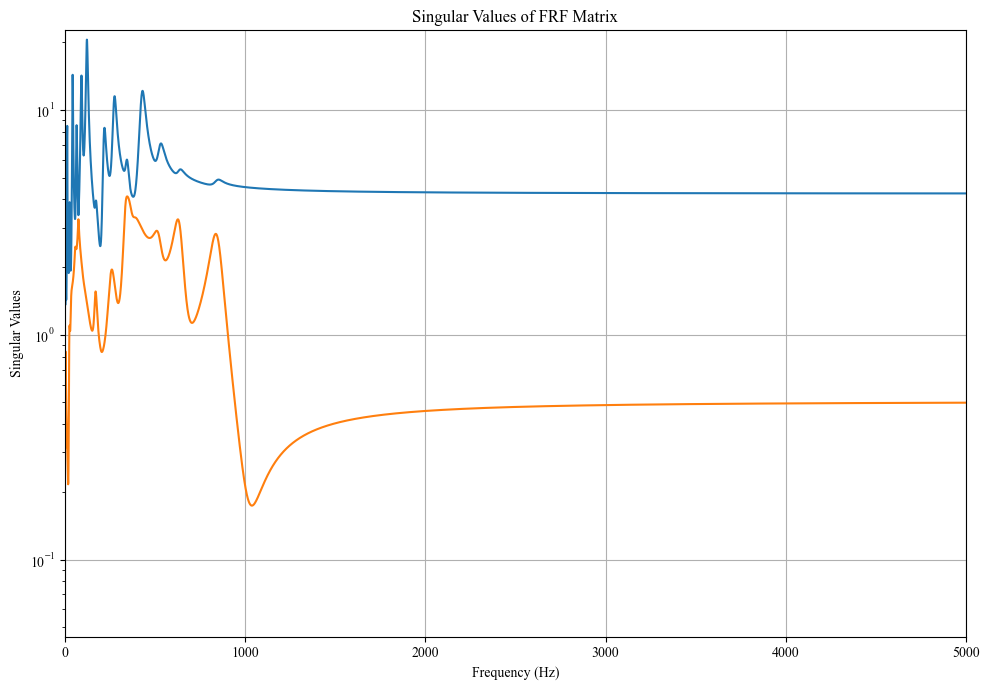

In [34]:
fig, ax = oversampled_frfs.extract_elements(slice(1,-1)).plot_singular_values();
ax.set_xlim(left=0, right=5000); fig.set_size_inches(10,7); fig.tight_layout()

The plot below shows a sample IRF that is computed from FRFs after removing the second singular value at all frequencies. Subjectively, it appears that the second singular value is significant to the FRF matrix at low frequencies (below ~900 Hz), based on the relative magnitudes of the first and second singular values. This IRF has significant apparent non-causalities, given the high amplitude ring up at the end of the time range.  

In [35]:
broadband_modified_frfs = tsvd_frfs(oversampled_frfs, 1)

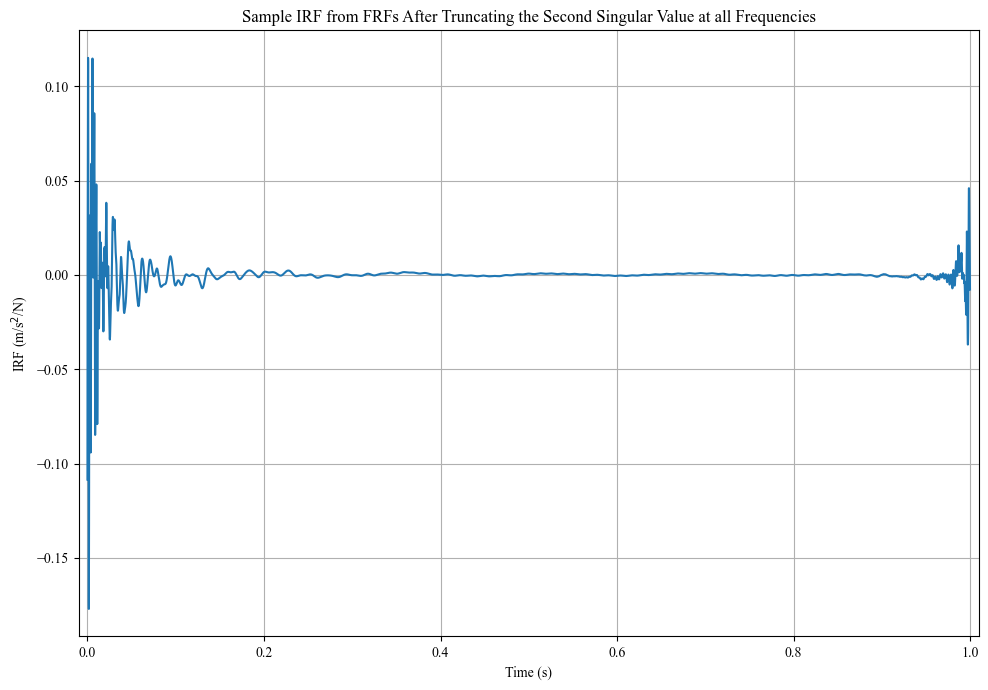

In [37]:
plt.figure(figsize=(10,7))
plt.plot(broadband_modified_frfs.ifft()[0,1].abscissa, broadband_modified_frfs.ifft()[0,1].ordinate)
plt.xlim(left=-0.01, right=T+0.01); plt.xlabel('Time (s)'); plt.ylabel('IRF (m/s$^2$/N)')
plt.grid(); plt.title('Sample IRF from FRFs After Truncating the Second Singular Value at all Frequencies')
plt.tight_layout(); 

Alternatively, the FRFs could be approximated after eliminating insignificant singular values. This is shown below by removing the second singular at frequencies greater than 1,000 Hz, where there is an order of magnitude difference between the first and second singular values. The IRF for this regularized approximation still shows some ring-up at the end of the time range but it is much less significant than what was seen when truncating the singular value over the whole time range. 

In [38]:
num_retained_values = np.ones(frequency.shape[0])*2
num_retained_values[1000:] = 1

freq_dependent_modified_frfs = tsvd_frfs(oversampled_frfs, num_retained_values)

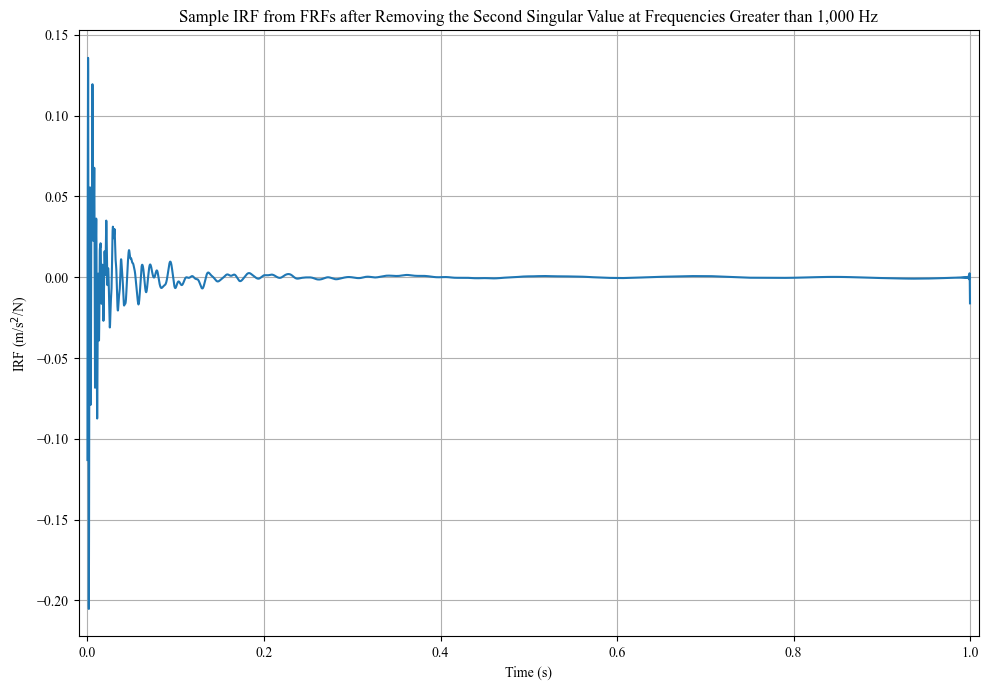

In [41]:
plt.figure(figsize=(10,7))
plt.plot(freq_dependent_modified_frfs.ifft()[0,1].abscissa, freq_dependent_modified_frfs.ifft()[0,1].ordinate)
plt.xlim(left=-0.01, right=T+0.01); plt.xlabel('Time (s)'); plt.ylabel('IRF (m/s$^2$/N)')
plt.grid(); plt.title('Sample IRF from FRFs after Removing the Second Singular Value at Frequencies Greater than 1,000 Hz');
plt.tight_layout()